# Transformer, LSTM, GRU, ESN

In [5]:
import pandas as pd
import glob
from pathlib import Path
import numpy as np

# Répertoire contenant les fichiers CSV
results_dir = '/Users/naowak/Thesis/code/STREAM-Dataset/baseline/results/run_4/'

# Charger tous les fichiers CSV
csv_files = sorted(glob.glob(f'{results_dir}*.csv'))
csv_files = [f for f in csv_files if 'dynamical_transformer' not in Path(f).name]  
print(f"Nombre de fichiers trouvés: {len(csv_files)}")

# Charger et afficher les premiers fichiers
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    # Ajouter le nom du fichier comme colonne
    df['model'] = Path(file).stem
    dfs.append(df)
    # print(f"Chargé: {Path(file).name} - Shape: {df.shape}")

# Concaténer tous les DataFrames
results_df = pd.concat(dfs, ignore_index=True)
results_df.to_csv('results.csv')
print(f"\nDataFrame concaténé - Shape: {results_df.shape}")
print(f"Colonnes: {results_df.columns.tolist()}")

# Préparer les données: plafonner les valeurs à 1
results_df['Test_Score_clipped'] = results_df['Test_Score'].clip(upper=1.0)

# Set ESN Learning Rate to -1
results_df.loc[results_df['Model'] == 'ESN', 'LR'] = -1

# Grouper par model/Task/Difficulty/Target_Params et obtenir le meilleur score
best_scores = results_df.groupby(['model', 'Task', 'Difficulty', 'Target_Params'])['Test_Score_clipped'].min().reset_index()
best_scores.columns = ['model', 'Task', 'Difficulty', 'Target_Params', 'Best_Test_Score']
# best_scores.head(10)

Nombre de fichiers trouvés: 19

DataFrame concaténé - Shape: (25760, 11)
Colonnes: ['Model', 'Task', 'Difficulty', 'Target_Params', 'Actual_Params', 'Seed', 'Category', 'Best_Val_Score', 'Test_Score', 'model', 'LR']


### Mean - Variance

In [13]:
import pandas as pd
import numpy as np

def highlight_best_score(row):
    means = []
    # Parcourir chaque cellule de la ligne pour extraire la moyenne
    for val in row:
        val_str = str(val).strip()
        if pd.isna(val) or val_str == 'nan':
            means.append(float('inf'))
        else:
            mean_val = float(val_str.split(' ± ')[0])
            means.append(mean_val)
            
    min_mean = min(means)
    
    if min_mean == float('inf'):
        return row
        
    # Reconstruire la ligne en gardant les noms de colonnes d'origine !
    new_row = {}
    for col, val, mean_val in zip(row.index, row, means):
        if mean_val == min_mean:
            new_row[col] = f"**{val}**"
        else:
            new_row[col] = val
            
    # On renvoie une Series Pandas au lieu d'une simple liste
    return pd.Series(new_row)

# 1. Charge ton dataframe global (fusionne tes CSV si tu en as plusieurs)
# df = pd.read_csv("tous_mes_resultats.csv")
df = results_df

# Remove models Dynamical_Transformer
df = df[~df['Model'].str.contains('DYNAMICAL_TRANSFORMER', case=False)]


# Fonctions de formatage pour respecter ta nomenclature
def format_difficulty(diff):
    return "SM" if diff.lower() == "small" else "MD"

def format_size(size):
    if size == 1000: return "1k"
    if size == 10000: return "10k"
    if size == 100000: return "100k"
    return str(size)

# 2. Agréger les 10 seeds pour avoir Mean ± Std
df_agg = df.groupby(['Task', 'Difficulty', 'Target_Params', 'Model', 'LR'])['Test_Score_clipped'].agg(['mean', 'std']).reset_index()
df_agg['mean'] = df_agg['mean'].round(2)

# Select only the best learning rate for each combination of Task/Difficulty/Target_Params/Model
df_agg = df_agg.sort_values(by=['Task', 'Difficulty', 'Target_Params', 'Model', 'mean'], ascending=[True, True, True, True, True])
df_agg = df_agg.groupby(['Task', 'Difficulty', 'Target_Params', 'Model']).first().reset_index()

# Créer la chaîne de caractères "Moyenne ± Std" (ex: 0.1234 ± 0.0012)
df_agg['Score_Formatted'] = df_agg.apply(
    lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1
)

# 3. Créer la colonne de label pour les lignes (ex: "adding_problem - SM - 1k")
df_agg['Row_Name'] = df_agg.apply(
    lambda row: f"{row['Task']} - {format_difficulty(row['Difficulty'])} - {format_size(row['Target_Params'])}", 
    axis=1
)

# 4. Ordonner correctement le dataframe avant le pivot pour garder l'ordre logique
# (Tri par Tâche, puis par Difficulté inversée pour avoir SM avant MD, puis par Taille)
df_agg = df_agg.sort_values(by=['Task', 'Difficulty', 'Target_Params'], ascending=[True, False, True])

# 5. Pivoter le tableau pour avoir les Modèles en colonnes
pivot_df = df_agg.pivot(index='Row_Name', columns='Model', values='Score_Formatted')

# Réappliquer l'ordre strict des lignes après le pivot
ordered_rows = df_agg['Row_Name'].unique()
pivot_df = pivot_df.reindex(ordered_rows)

# Appliquer la fonction sur chaque ligne du tableau (axis=1)
pivot_df = pivot_df.apply(highlight_best_score, axis=1)

# Renommer l'index pour que la première colonne s'appelle "Tâches"
pivot_df.index.name = "Tâches"
# Order columns by model name
# pivot_df = pivot_df.reindex(columns=['ESN', 'GRU', 'LSTM', 'XLSTM', 'TRANSFORMER_DECODER', 'TRANSFORMER_ENCDEC'])

# 6. Exporter le tableau en format Markdown
markdown_table = pivot_df.to_markdown()

print(markdown_table)

| Tâches                                    | ESN             | GRU             | LSTM            | MAMBA           | TRANSFORMER_DECODER   | TRANSFORMER_ENCDEC   | XLSTM           |
|:------------------------------------------|:----------------|:----------------|:----------------|:----------------|:----------------------|:---------------------|:----------------|
| adding_problem - SM - 1k                  | 0.47 ± 0.09     | **0.08 ± 0.05** | 0.50 ± 0.31     | 0.63 ± 0.21     | 0.56 ± 0.24           | 0.69 ± 0.06          | 0.32 ± 0.37     |
| adding_problem - SM - 10k                 | **0.02 ± 0.03** | 0.13 ± 0.13     | 0.36 ± 0.33     | 0.63 ± 0.20     | 0.15 ± 0.22           | 0.42 ± 0.27          | 0.07 ± 0.06     |
| adding_problem - SM - 100k                | nan             | 0.16 ± 0.10     | 0.55 ± 0.29     | 0.61 ± 0.23     | **0.04 ± 0.03**       | 0.22 ± 0.32          | 0.06 ± 0.07     |
| adding_problem - MD - 1k                  | 0.85 ± 0.02     | **0.01 ± 0.01** | 0.0

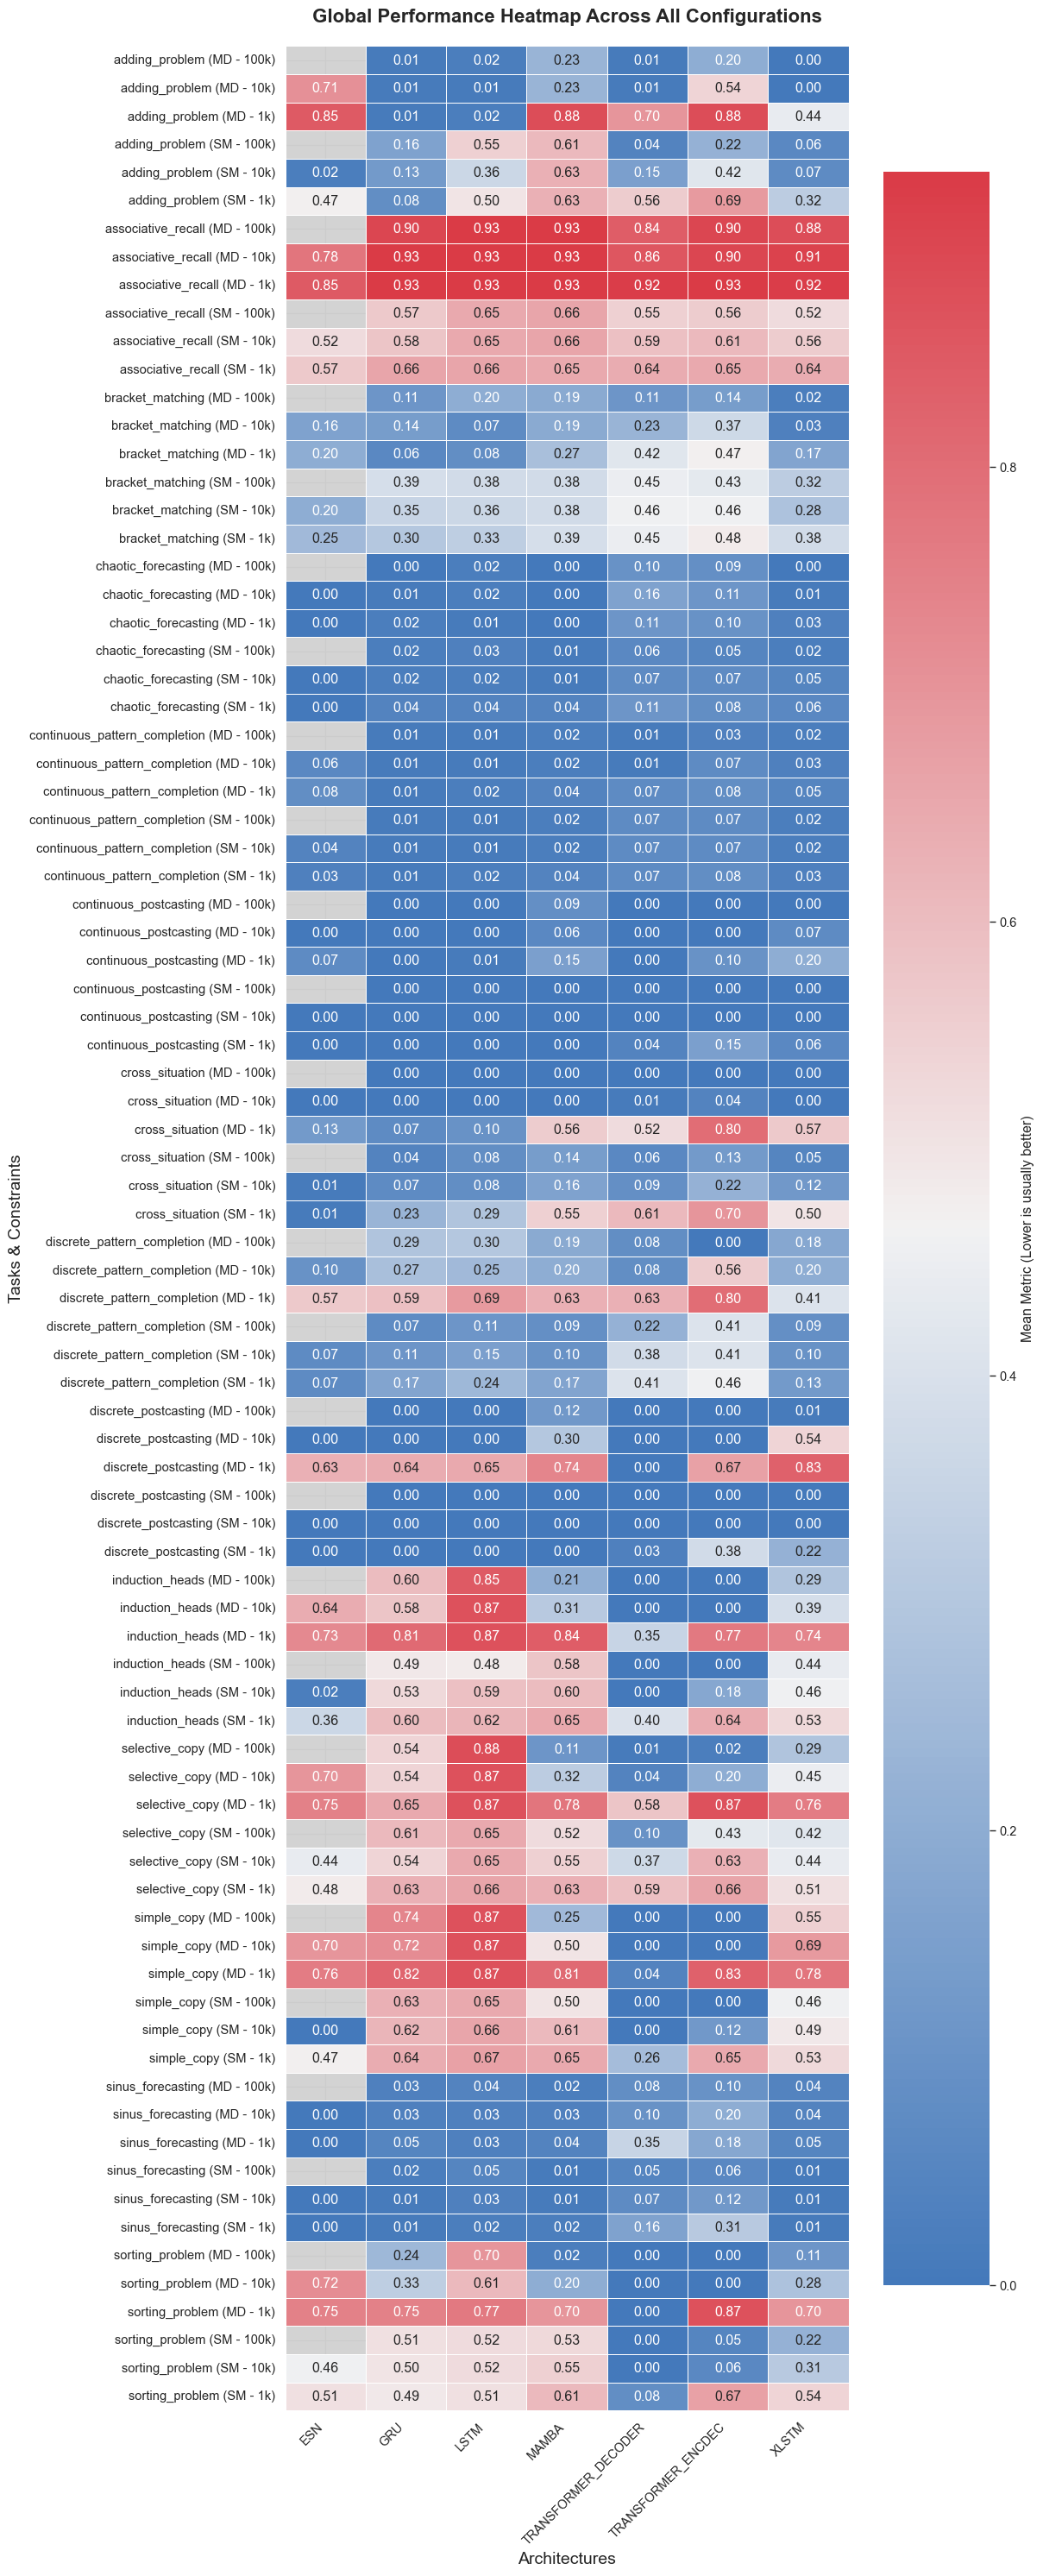

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PARSING DES DONNÉES
# J'ai copié votre tableau markdown directement ici.
markdown_table = pivot_df.to_markdown()

# Nettoyage et transformation en DataFrame
# On ignore les lignes vides et la ligne de séparation markdown (qui contient '---')
lines = [line.strip().strip('|') for line in markdown_table.strip().split('\n') if line.strip() and '---' not in line]
header = [col.strip() for col in lines[0].split('|')]
data = []

for line in lines[1:]:
    row = [col.strip() for col in line.split('|')]
    task_parts = row[0].split(' - ')
    
    if len(task_parts) != 3:
        continue
        
    task_name = task_parts[0].strip()
    difficulty = task_parts[1].strip()
    size = task_parts[2].strip()
    
    for i in range(1, len(row)):
        val_str = row[i].replace('**', '').strip()
        if val_str == 'nan':
            mean_val = np.nan
        else:
            mean_val = float(val_str.split('±')[0].strip())
        
        data.append({
            'Task': task_name,
            'Difficulty': difficulty,
            'Size': size,
            'Model': header[i],
            'Mean': mean_val
        })

df = pd.DataFrame(data)
df['Size'] = pd.Categorical(df['Size'], categories=['1k', '10k', '100k'], ordered=True)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("tab10", n_colors=8)

# ==========================================
# GRAPHIQUE 1 : Évolution selon la longueur (Faceted Line Plot)
# ==========================================
# tasks_to_plot = ['adding_problem', 'associative_recall', 'bracket_matching', 'simple_copy']
# df_filtered = df[df['Task'].isin(tasks_to_plot)]

# g = sns.relplot(
#     data=df, 
#     x='Size', y='Mean', hue='Model', 
#     col='Task', row='Difficulty', 
#     kind='line', marker='o', linewidth=2.5, markersize=8,
#     palette=palette, height=3, aspect=1.2,
#     facet_kws={'sharey': False}
# )

# g.set_titles(col_template="{col_name}", row_template="{row_name}")
# g.set_axis_labels("Model Size", "Error/Metric Mean")
# sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 0), ncol=4, title=None, frameon=True)
# plt.subplots_adjust(bottom=0.15)
# g.fig.suptitle("Model Performance Scaling across Model Sizes", y=1.05, fontsize=16, fontweight='bold')
# plt.savefig("scaling_plot.pdf", bbox_inches='tight')
# plt.show()

# ==========================================
# GRAPHIQUE 2 : Carte de Chaleur (Heatmap) des performances globales
# ==========================================
df['Config'] = df['Task'] + " (" + df['Difficulty'] + " - " + df['Size'].astype(str) + ")"
pivot_df = df.pivot(index='Config', columns='Model', values='Mean')

plt.figure(figsize=(12, 30))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Définir la couleur de fond de l'axe actuel pour que les 'NaN' apparaissent en gris
plt.gca().set_facecolor('lightgrey')

sns.heatmap(
    pivot_df, 
    cmap=cmap, 
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Mean Metric (Lower is usually better)'},
    linewidths=.5
)
plt.title("Global Performance Heatmap Across All Configurations", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Architectures", fontsize=14)
plt.ylabel("Tasks & Constraints", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("heatmap_performance_mean.pdf", bbox_inches='tight')
plt.show()

# ==========================================
# GRAPHIQUE 3 : Rang Moyen (Average Rank)
# ==========================================
# df['Rank'] = df.groupby('Config')['Mean'].rank(method='min', na_option='bottom')
# avg_rank = df.groupby('Model')['Rank'].mean().sort_values()

# plt.figure(figsize=(10, 6))
# bars = sns.barplot(x=avg_rank.index, y=avg_rank.values, palette="viridis")
# plt.title("Average Rank Across All Tasks (Lower is Better)", fontsize=16, fontweight='bold')
# plt.ylabel("Average Rank", fontsize=14)
# plt.xlabel("Model Architecture", fontsize=14)
# plt.xticks(rotation=30, ha='right')

# for p in bars.patches:
#     bars.annotate(format(p.get_height(), '.2f'), 
#                    (p.get_x() + p.get_width() / 2., p.get_height()), 
#                    ha = 'center', va = 'center', 
#                    xytext = (0, 9), 
#                    textcoords = 'offset points')

# plt.tight_layout()
# plt.savefig("average_rank.pdf", bbox_inches='tight')
# plt.show()

### Best@10

In [17]:
import pandas as pd
import glob
from pathlib import Path
import numpy as np

# --- 1. CHARGEMENT DES DONNÉES ---
results_dir = '/Users/naowak/Thesis/code/STREAM-Dataset/baseline/results/run_4/'
csv_files = sorted(glob.glob(f'{results_dir}*.csv'))
csv_files = [f for f in csv_files if 'dynamical_transformer' not in Path(f).name]

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    
    # Sécurité: Si pour une raison quelconque la colonne 'Model' n'est pas dans le CSV,
    # on extrait le nom de l'architecture depuis le nom du fichier (ex: esn_10k -> ESN)
    if 'Model' not in df.columns:
        base_model = Path(file).stem.split('_1')[0].upper()
        df['Model'] = base_model
        
    dfs.append(df)

results_df = pd.concat(dfs, ignore_index=True)

# --- 2. PRÉPARATION ---
results_df['Test_Score_clipped'] = results_df['Test_Score'].clip(upper=1.0)

# Grouper par Model (l'architecture pure), Task, Difficulty, Target_Params
# Et prendre .min() car pour les Error Rate / MSE, plus c'est bas, meilleur c'est !
# best_scores = results_df.groupby(['Model', 'Task', 'Difficulty', 'Target_Params'])['Test_Score_clipped'].min().reset_index()
# best_scores.columns = ['Model', 'Task', 'Difficulty', 'Target_Params', 'Best_Test_Score']
best_scores = results_df.groupby(['Model', 'Task', 'Difficulty'])['Test_Score_clipped'].min().reset_index()
best_scores.columns = ['Model', 'Task', 'Difficulty', 'Best_Test_Score']
best_scores['Best_Test_Score'] = best_scores['Best_Test_Score'].round(2)

# --- 3. FORMATAGE POUR LE TABLEAU MARKDOWN ---
def format_difficulty(diff):
    return "SM" if diff.lower() == "small" else "MD"

def format_size(size):
    if size == 1000: return "1k"
    if size == 10000: return "10k"
    if size == 100000: return "100k"
    return str(size)

# Création du nom des lignes
best_scores['Row_Name'] = best_scores.apply(
    lambda row: f"{row['Task']} - {format_difficulty(row['Difficulty'])}", 
    # lambda row: f"{row['Task']} - {format_difficulty(row['Difficulty'])} - {format_size(row['Target_Params'])}", 
    axis=1
)

# Tri logique
best_scores = best_scores.sort_values(by=['Task', 'Difficulty'], ascending=[True, False])
# best_scores = best_scores.sort_values(by=['Task', 'Difficulty', 'Target_Params'], ascending=[True, False, True])

# PIVOT avec Model en colonne !
pivot_df = best_scores.pivot(index='Row_Name', columns='Model', values='Best_Test_Score')

# Réappliquer l'ordre strict des lignes
ordered_rows = best_scores['Row_Name'].unique()
pivot_df = pivot_df.reindex(ordered_rows)

# Fonction pour mettre le meilleur en gras
def highlight_best_single_score(row):
    min_val = row.min() # Ignore les NaN
    new_row = {}
    for col, val in row.items():
        if pd.isna(val):
            new_row[col] = "NaN"
        elif val == min_val:
            new_row[col] = f"**{val:.2f}**"
        else:
            new_row[col] = f"{val:.2f}"
    return pd.Series(new_row)

# Application du gras
pivot_df = pivot_df.apply(highlight_best_single_score, axis=1)

# Esthétique du tableau final
pivot_df.index.name = "Tâches"
pivot_df.columns.name = None # Enlève le label "Model" au dessus des colonnes

# Affichage du Markdown
print(pivot_df.to_markdown())

| Tâches                             | ESN      | GRU      | LSTM     | MAMBA    | TRANSFORMER_DECODER   | TRANSFORMER_ENCDEC   | XLSTM    |
|:-----------------------------------|:---------|:---------|:---------|:---------|:----------------------|:---------------------|:---------|
| adding_problem - SM                | **0.00** | **0.00** | 0.02     | 0.01     | **0.00**              | **0.00**             | **0.00** |
| adding_problem - MD                | 0.69     | **0.00** | **0.00** | **0.00** | **0.00**              | **0.00**             | **0.00** |
| associative_recall - SM            | 0.44     | **0.35** | 0.57     | 0.59     | 0.36                  | 0.39                 | 0.40     |
| associative_recall - MD            | 0.76     | 0.88     | 0.91     | 0.91     | **0.67**              | 0.78                 | 0.85     |
| bracket_matching - SM              | 0.13     | 0.18     | 0.21     | 0.29     | 0.19                  | 0.27                 | **0.06** |
| bracket_mat

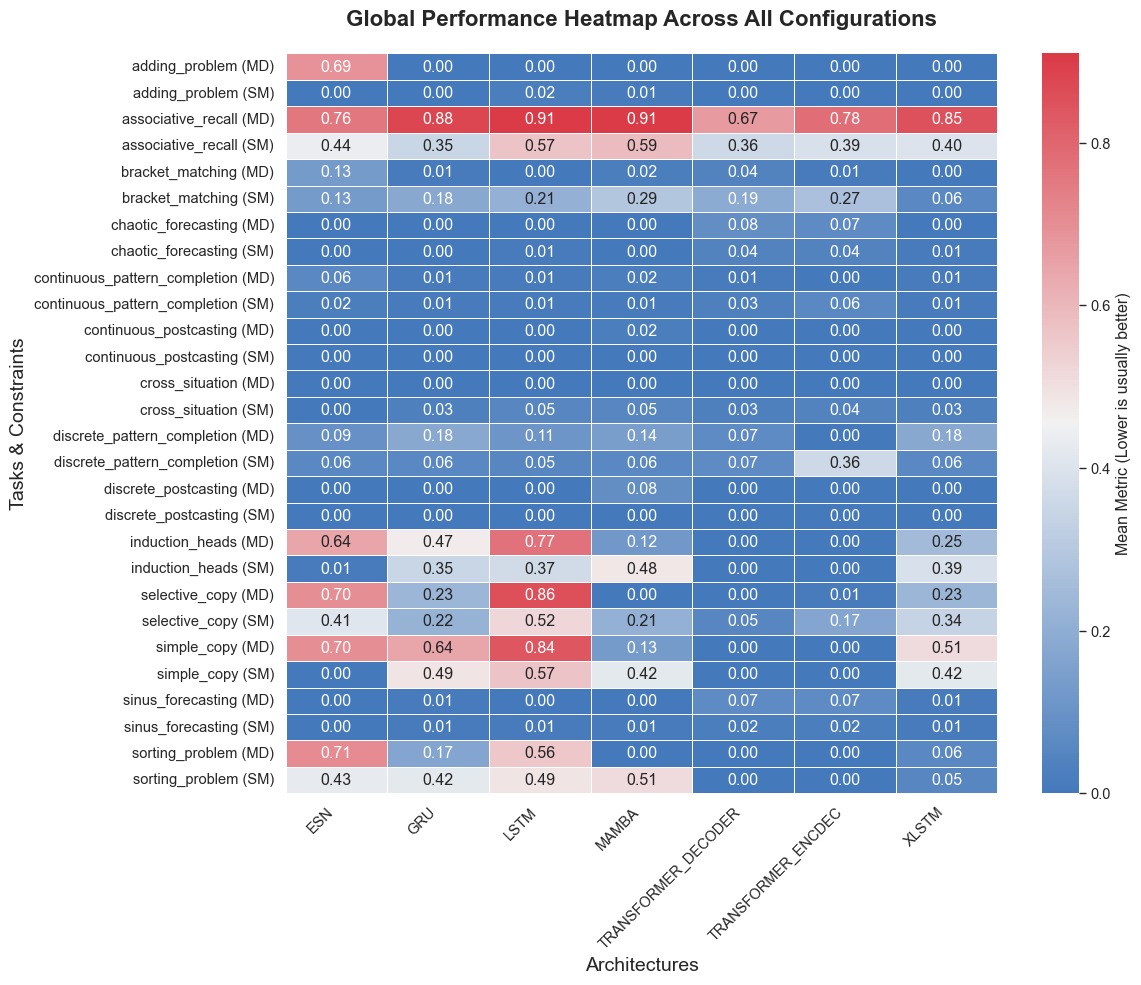

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PARSING DES DONNÉES
# J'ai copié votre tableau markdown directement ici.
markdown_table = pivot_df.to_markdown()

# Nettoyage et transformation en DataFrame
# On ignore les lignes vides et la ligne de séparation markdown (qui contient '---')
lines = [line.strip().strip('|') for line in markdown_table.strip().split('\n') if line.strip() and '---' not in line]
header = [col.strip() for col in lines[0].split('|')]
data = []

for line in lines[1:]:
    row = [col.strip() for col in line.split('|')]
    task_parts = row[0].split(' - ')
    
    if len(task_parts) != 2:
        continue
        
    task_name = task_parts[0].strip()
    difficulty = task_parts[1].strip()
    # size = task_parts[2].strip()
    
    for i in range(1, len(row)):
        val_str = row[i].replace('**', '').strip()
        if val_str == 'nan':
            mean_val = np.nan
        else:
            mean_val = float(val_str.split('±')[0].strip())
        
        data.append({
            'Task': task_name,
            'Difficulty': difficulty,
            # 'Size': size,
            'Model': header[i],
            'Mean': mean_val
        })

df = pd.DataFrame(data)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("tab10", n_colors=8)

# ==========================================
# GRAPHIQUE 1 : Évolution selon la longueur (Faceted Line Plot)
# ==========================================
# tasks_to_plot = ['adding_problem', 'associative_recall', 'bracket_matching', 'simple_copy']
# df_filtered = df[df['Task'].isin(tasks_to_plot)]

# g = sns.relplot(
#     data=df, 
#     x='Size', y='Mean', hue='Model', 
#     col='Task', row='Difficulty', 
#     kind='line', marker='o', linewidth=2.5, markersize=8,
#     palette=palette, height=3, aspect=1.2,
#     facet_kws={'sharey': False}
# )

# g.set_titles(col_template="{col_name}", row_template="{row_name}")
# g.set_axis_labels("Model Size", "Error/Metric Mean")
# sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 0), ncol=4, title=None, frameon=True)
# plt.subplots_adjust(bottom=0.15)
# g.fig.suptitle("Model Performance Scaling across Model Sizes", y=1.05, fontsize=16, fontweight='bold')
# plt.savefig("scaling_plot.pdf", bbox_inches='tight')
# plt.show()

# ==========================================
# GRAPHIQUE 2 : Carte de Chaleur (Heatmap) des performances globales
# ==========================================
df['Config'] = df['Task'] + " (" + df['Difficulty'] + ")"
pivot_df = df.pivot(index='Config', columns='Model', values='Mean')
# order = ['dynamic_transformer', 'mamba', 'esn', 'gru', 'lstm', 'xlstm', 'transformer_decoder', 'transformer_encdec']
# pivot_df = pivot_df.reindex(columns=order, axis=1)  
# pivot_df = pivot_df[order]  # Réordonner les colonnes selon l'ordre souhaité

plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Définir la couleur de fond de l'axe actuel pour que les 'NaN' apparaissent en gris
plt.gca().set_facecolor('lightgrey')

sns.heatmap(
    pivot_df, 
    cmap=cmap, 
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Mean Metric (Lower is usually better)'},
    linewidths=.5
)
plt.title("Global Performance Heatmap Across All Configurations", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Architectures", fontsize=14)
plt.ylabel("Tasks & Constraints", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("heatmap_performance_best.pdf", bbox_inches='tight')
plt.show()

# ==========================================
# GRAPHIQUE 3 : Rang Moyen (Average Rank)
# ==========================================
# df['Rank'] = df.groupby('Config')['Mean'].rank(method='min', na_option='bottom')
# avg_rank = df.groupby('Model')['Rank'].mean().sort_values()

# plt.figure(figsize=(10, 6))
# bars = sns.barplot(x=avg_rank.index, y=avg_rank.values, palette="viridis")
# plt.title("Average Rank Across All Tasks (Lower is Better)", fontsize=16, fontweight='bold')
# plt.ylabel("Average Rank", fontsize=14)
# plt.xlabel("Model Architecture", fontsize=14)
# plt.xticks(rotation=30, ha='right')

# for p in bars.patches:
#     bars.annotate(format(p.get_height(), '.2f'), 
#                    (p.get_x() + p.get_width() / 2., p.get_height()), 
#                    ha = 'center', va = 'center', 
#                    xytext = (0, 9), 
#                    textcoords = 'offset points')

# plt.tight_layout()
# plt.savefig("average_rank.pdf", bbox_inches='tight')
# plt.show()

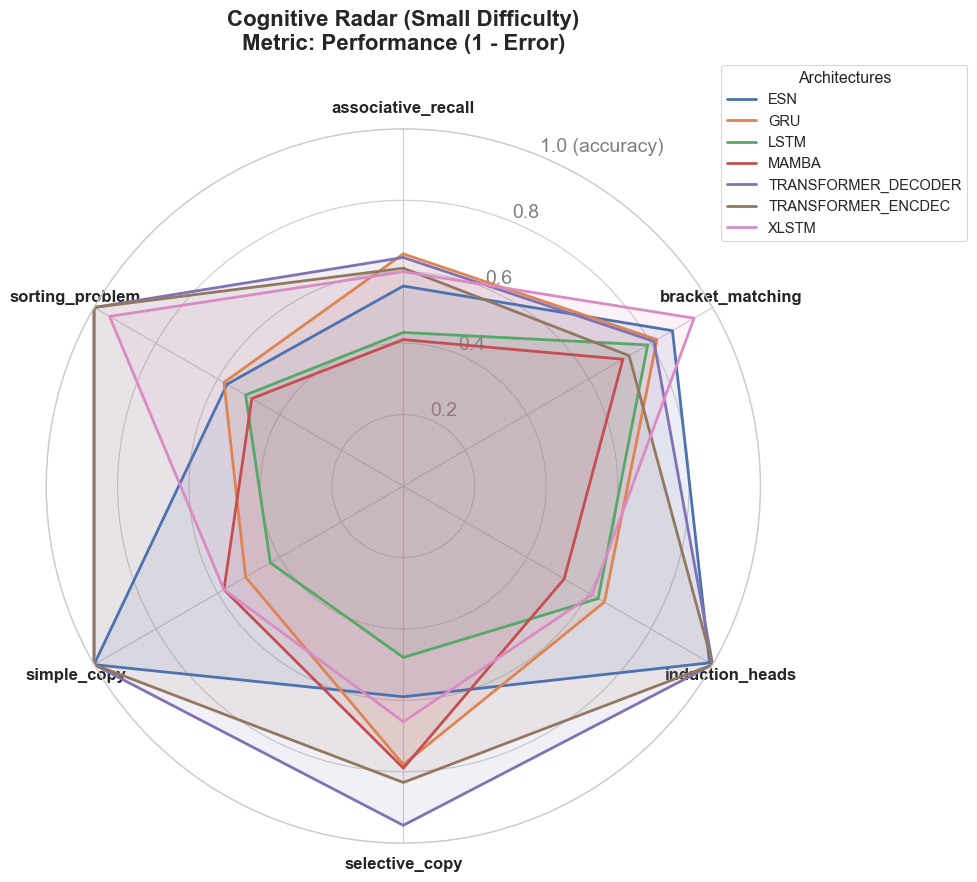

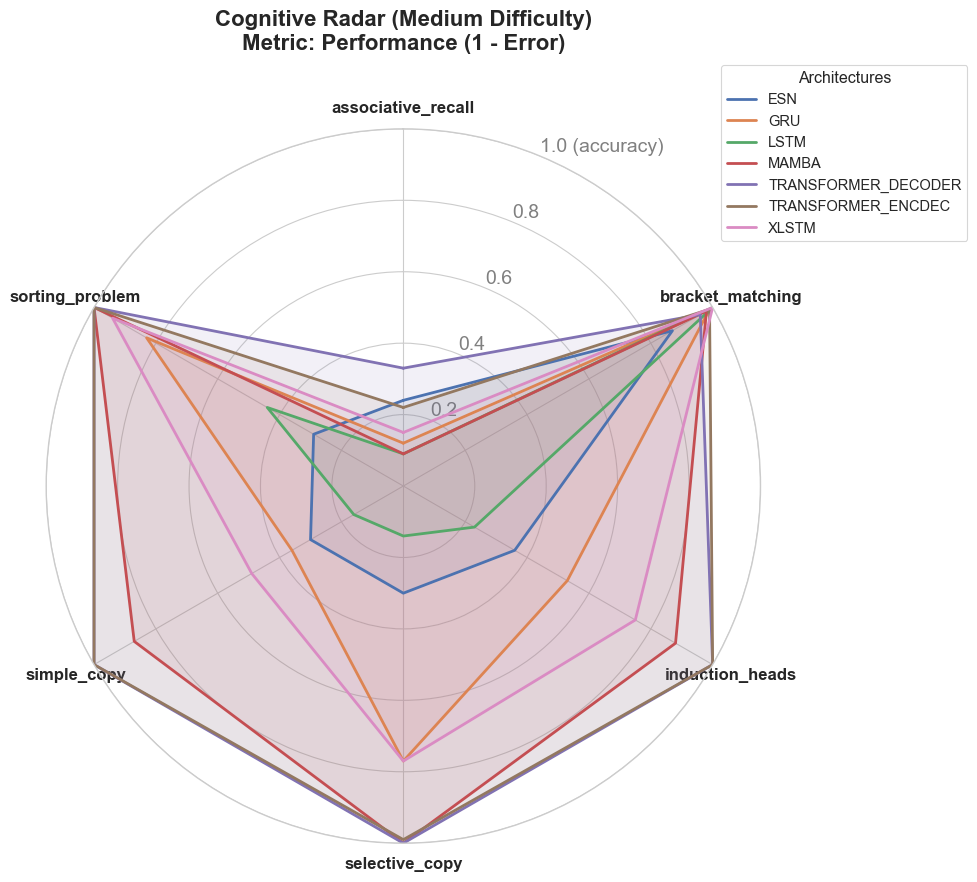

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Chargement des données brutes (Markdown)
markdown_data = pivot_df.to_markdown()

# Nettoyage et parsing du Markdown
lines = [line.strip() for line in markdown_data.strip().split('\n') if line.strip()]
lines = [line for line in lines if not line.startswith('|:')]
csv_data = '\n'.join(lines)

df = pd.read_csv(io.StringIO(csv_data), sep='|').iloc[:, 1:-1]
df.columns = df.columns.str.strip()
df['Tâches'] = df['Tâches'].str.strip()

# Conversion des scores en numériques
for col in df.columns[1:]:
    df[col] = df[col].astype(str).str.replace('*', '', regex=False).str.strip().astype(float)

# 2. Filtrer sur les 6 tâches discriminantes
target_tasks = [
    # 'discrete_pattern_completion',
    "bracket_matching",
    'associative_recall',
    'induction_heads',
    'selective_copy',
    'simple_copy',
    'sorting_problem'
]

target_names = [
    # 'discrete_pattern_completion': 'Discrete Pattern Completion',
    "Bracket Matching",
    'Associative Recall',
    'Induction Heads',
    'Selective Copy',
    'Simple Copy',
    'Sorting Problem'
]

df['Base_Task'] = df['Tâches'].apply(lambda x: x.split(' - ')[0])
df_filtered = df[df['Base_Task'].isin(target_tasks)].copy()

df_sm = df_filtered[df_filtered['Tâches'].str.contains('SM')].copy()
df_md = df_filtered[df_filtered['Tâches'].str.contains('MD')].copy()

# 3. Fonction pour générer un Radar Chart professionnel
def plot_radar_chart(df_split, title, filename=None):
    if df_split.empty:
        print(f"Erreur : Le dataframe pour '{title}' est vide.")
        return None
        
    labels = df_split['Base_Task'].tolist()
    models = df_split.columns[1:-1]
    
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12, weight='bold')
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        values = df_split[model].tolist()
        
        # INVERSION : 0.00 d'erreur = 1.0 de performance
        values_plot = [1 - v for v in values]
        values_plot += values_plot[:1] 
        
        ax.plot(angles, values_plot, linewidth=2, label=model)
        ax.fill(angles, values_plot, alpha=0.1) 
        
    ax.set_ylim(0, 1.00)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0 (accuracy)"], color="grey", size=14)
    
    plt.title(title, size=16, weight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Architectures")
    
    plt.tight_layout()
    plt.show()

# 4. Tracé des graphiques
plot_radar_chart(df_sm, "Cognitive Radar (Small Difficulty)\nMetric: Performance (1 - Error)")
plot_radar_chart(df_md, "Cognitive Radar (Medium Difficulty)\nMetric: Performance (1 - Error)")


In [19]:
(1-df_sm.drop('Tâches', axis=1).set_index('Base_Task').T).to_csv("extracted_sm.csv")
(1-df_md.drop('Tâches', axis=1).set_index('Base_Task').T).to_csv("extracted_md.csv")

,Tâches,ESN,GRU,LSTM,MAMBA,TRANSFORMER_DECODER,TRANSFORMER_ENCDEC,XLSTM,Base_Task
3,associative_recall - MD,0.76,0.88,0.91,0.91,0.67,0.78,0.85,associative_recall
5,bracket_matching - MD,0.13,0.01,0.00,0.02,0.04,0.01,0.00,bracket_matching
19,induction_heads - MD,0.73,0.47,0.77,0.12,0.00,0.00,0.25,induction_heads
21,selective_copy - MD,0.70,0.23,0.86,0.00,0.00,0.01,0.23,selective_copy
23,simple_copy - MD,0.70,0.64,0.84,0.13,0.00,0.00,0.51,simple_copy
27,sorting_problem - MD,0.71,0.17,0.56,0.00,0.00,0.00,0.06,sorting_problem


In [4]:
import pandas as pd
import io
import re

def markdown_to_latex(md_table):
    # 1. Nettoyage du texte Markdown pour LaTeX
    # Convertit **texte** en \textbf{texte}
    md_table = re.sub(r'\*\*(.*?)\*\*', r'\\textbf{\1}', md_table)
    
    # 2. Lecture du tableau via Pandas
    # On utilise sep='|' et on retire les colonnes vides créées par les bords du tableau
    df = pd.read_csv(io.StringIO(md_table), sep='|', skipinitialspace=True).dropna(axis=1, how='all')
    
    # Nettoyage des noms de colonnes et des espaces
    df.columns = [c.strip() for c in df.columns]
    df = df.apply(lambda x: x.strip() if isinstance(x, str) else x)
    
    # Supprimer la ligne de séparation (---) si elle est lue comme une ligne de données
    df = df[~df.iloc[:, 0].str.contains('^:?---')]

    # 3. Conversion en LaTeX
    latex_code = df.to_latex(
        index=False, 
        column_format='l' + 'c' * (len(df.columns) - 1),
        caption="Résultats",
        label="tab:results",
        escape=False  # Important pour garder les commandes \textbf et symboles spéciaux
    )
    
    return latex_code

# Votre tableau
with open("best_overall.md", "r") as f:
    markdown_input = f.read()

print(markdown_to_latex(markdown_input))

\begin{table}
\caption{Résultats}
\label{tab:results}
\begin{tabular}{lccccccc}
\toprule
Tâches & ESN & GRU & LSTM & MAMBA & TRANSFORMER_DECODER & TRANSFORMER_ENCDEC & XLSTM \\
\midrule
adding_problem - SM                 & \textbf{0.00}  & \textbf{0.00}  & 0.02      & 0.01      & \textbf{0.00}               & \textbf{0.00}              & \textbf{0.00}  \\
adding_problem - MD                 & 0.69      & \textbf{0.00}  & \textbf{0.00}  & \textbf{0.00}  & \textbf{0.00}               & \textbf{0.00}              & \textbf{0.00}  \\
associative_recall - SM             & 0.44      & \textbf{0.35}  & 0.57      & 0.59      & 0.36                   & 0.39                  & 0.40      \\
associative_recall - MD             & 0.76      & 0.88      & 0.91      & 0.91      & \textbf{0.67}               & 0.78                  & 0.85      \\
bracket_matching - SM               & 0.13      & 0.18      & 0.21      & 0.29      & 0.19                   & 0.27                  & \textbf{0.06}  \\
brac

In [2]:
markdown_input

'| Tâches                                    | ESN             | GRU             | LSTM            | MAMBA           | TRANSFORMER_DECODER   | TRANSFORMER_ENCDEC   | XLSTM           |\n|:------------------------------------------|:----------------|:----------------|:----------------|:----------------|:----------------------|:---------------------|:----------------|\n| adding_problem - SM - 1k                  | 0.47 ± 0.09     | **0.08 ± 0.05** | 0.50 ± 0.31     | 0.63 ± 0.21     | 0.56 ± 0.24           | 0.69 ± 0.06          | 0.32 ± 0.37     |\n| adding_problem - SM - 10k                 | **0.02 ± 0.03** | 0.13 ± 0.13     | 0.36 ± 0.33     | 0.63 ± 0.20     | 0.15 ± 0.22           | 0.42 ± 0.27          | 0.07 ± 0.06     |\n| adding_problem - SM - 100k                | nan             | 0.16 ± 0.10     | 0.55 ± 0.29     | 0.61 ± 0.23     | **0.04 ± 0.03**       | 0.22 ± 0.32          | 0.06 ± 0.07     |\n| adding_problem - MD - 1k                  | 0.85 ± 0.02     | **0.01 ± 0.01**